In [92]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from analysis.gravnet.model import NeutrinoGravNetNodesGraphFaser
from analysis.utils.colors import TangoColors
from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.models import GraphClassifier, MuonHitNetClassifier
from analysis.utils.plot_utils import setup
from analysis.utils.torch_geometric_utils import (
    evaluate_gravnet_model,
    evaluate_pointnetpp_model,
)
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
setup()

In [3]:
@dataclass
class HitType:
    idx: int
    label: str
    latex_name: str
    color: str = "black"


other_hit = HitType(0, "other", "Other", TangoColors.sky_blue)
e_hit = HitType(1, "e", r"$e^{\pm}$", TangoColors.scarlet_red)
mu_hit = HitType(2, "mu", r"$\mu^{\pm}$", TangoColors.chameleon)
# hits = [other_hit, other_e_hit, primary_e_hit, primary_mu_hit]
hits = [other_hit, e_hit, mu_hit]

In [4]:
@dataclass
class NuType:
    idx: int
    label: str
    latex_name: str


nun = NuType(0, "nun", "NC")
nue = NuType(1, "nue", r"CC $\nu_{e}$")
num = NuType(2, "num", r"CC $\nu_{\mu}$")
nus = [nun, nue, num]

# Main


In [75]:
model = "gravnet_nodes_graph_faser_all_events_det_8mm_0_scint_layer"
weights_dir_path = get_weights_path() / model
weights_path = weights_dir_path / "best_model.pt"
figures_path = get_figures_path() / model
figures_path.mkdir(parents=True, exist_ok=True)

In [76]:
train_metrics = np.load(weights_dir_path / "training_metrics.npz")

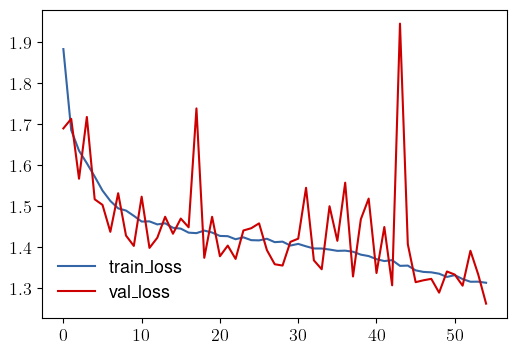

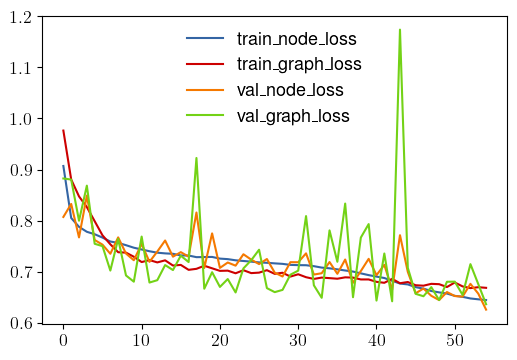

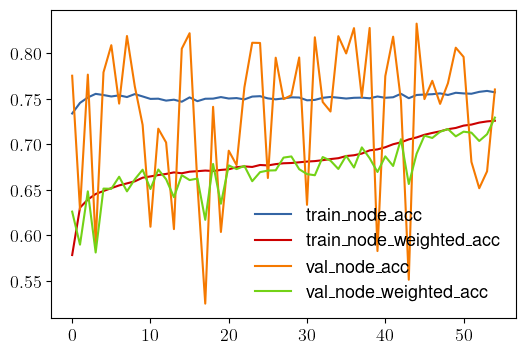

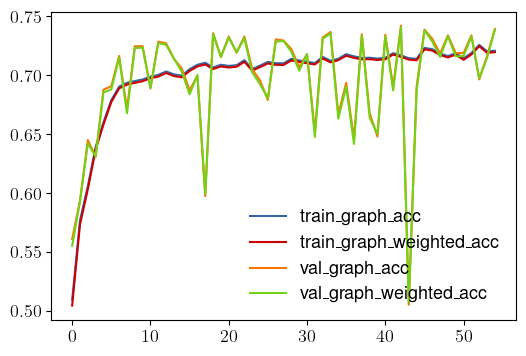

In [83]:
epochs = np.arange(55)
fig, ax = plt.subplots(figsize=(6, 4))
for key in ["train_loss", "val_loss"]:
    ax.plot(epochs, train_metrics[key], label=key)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for key in ["train_node_loss", "train_graph_loss", "val_node_loss", "val_graph_loss"]:
    ax.plot(epochs, train_metrics[key], label=key)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for key in [
    "train_node_acc",
    "train_node_weighted_acc",
    "val_node_acc",
    "val_node_weighted_acc",
]:
    ax.plot(epochs, train_metrics[key], label=key)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for key in [
    "train_graph_acc",
    "train_graph_weighted_acc",
    "val_graph_acc",
    "val_graph_weighted_acc",
]:
    ax.plot(epochs, train_metrics[key], label=key)
ax.legend()
plt.show()

In [84]:
# Test dataset
# data_path = get_torch_path() / "pointnetpp/test_dataset.pt"
# test_dataset = torch.load(data_path)
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)

In [85]:
def get_str_from_run(run: int) -> str:
    """Convert run number to string label."""
    if run % 4 == 0:
        return "nue"
    elif run % 4 == 1:
        return "num"
    elif run % 4 == 2:
        return "nut"
    elif run % 4 == 3:
        return "nun"

In [87]:
def loda_data(
    run: int, chunks: list[int], data_dir: str, num_events: int | None = None
) -> list[torch.Tensor]:
    torch_path = get_torch_path()
    dataset = []
    truth_dfs = []
    for chunk in chunks:
        run_str = get_str_from_run(run)
        chunk_path = torch_path / f"{run}/{data_dir}"
        chunk_data = torch.load(
            chunk_path / f"{run_str}_{chunk:03d}.pt", weights_only=False
        )
        truth_df = pd.read_parquet(chunk_path / f"{run_str}_{chunk:03d}_truth.parq")
        if num_events is not None:
            chunk_data = chunk_data[:num_events]
            truth_df = truth_df.iloc[:num_events]
        dataset.extend(chunk_data)
        truth_dfs.append(truth_df)
    return dataset, pd.concat(truth_dfs, ignore_index=True)

In [97]:
chunks = [5, 6]
num_events = 500
data_dir = "pointnetpp_faser_all_events"
nue_data, nue_truth = loda_data(
    run=10028, chunks=chunks, data_dir=data_dir, num_events=num_events
)
num_data, num_truth = loda_data(
    run=10029, chunks=chunks, data_dir=data_dir, num_events=num_events
)
nun_data, nun_truth = loda_data(
    run=10031, chunks=chunks, data_dir=data_dir, num_events=num_events
)
dataset = nue_data + num_data + nun_data
data_loader = DataLoader(dataset)
print(len(nue_data), len(num_data), len(nun_data), len(dataset))

1000 1000 1000 3000


In [113]:
truth_df = pd.concat([nue_truth, num_truth, nun_truth], ignore_index=True)

In [98]:
device = get_device("cpu")

model = NeutrinoGravNetNodesGraphFaser(
    input_dim=dataset[0].x.shape[1],
    faser_dim=dataset[0].x_faser.shape[0],
    num_graph_classes=len(nus),
    num_node_classes=len(hits),
)
model = model.to(device)

load_weights(model, device=device, weights_path=weights_path)

Using device: cpu


In [99]:
y_node_true, y_node_pred, y_node_prob, y_graph_true, y_graph_pred, y_graph_prob = (
    evaluate_pointnetpp_model(
        model=model,
        test_loader=data_loader,
        device=device,
        use_faser=True,
    )
)

Evaluating: 100%|██████████| 3000/3000 [04:13<00:00, 11.85it/s]


In [100]:
y_node_true_flat = np.concatenate(y_node_true)
y_node_pred_flat = np.concatenate(y_node_pred)
y_node_prob_flat = np.concatenate(y_node_prob)

y_graph_true_flat = np.concatenate(y_graph_true)
y_graph_pred_flat = np.concatenate(y_graph_pred)
y_graph_prob_flat = np.concatenate(y_graph_prob)

In [101]:
acc_dict = get_accuracy_dict(
    y_true=y_node_true_flat,
    y_pred=y_node_pred_flat,
    class_names=[hit.label for hit in hits],
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

other: 75.9%
e: 76.8%
mu: 67.0%
average: 73.2%


In [102]:
acc_dict = get_accuracy_dict(
    y_true=y_graph_true_flat,
    y_pred=y_graph_pred_flat,
    class_names=[nu.label for nu in nus],
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

nun: 63.5%
nue: 74.3%
num: 80.2%
average: 72.7%


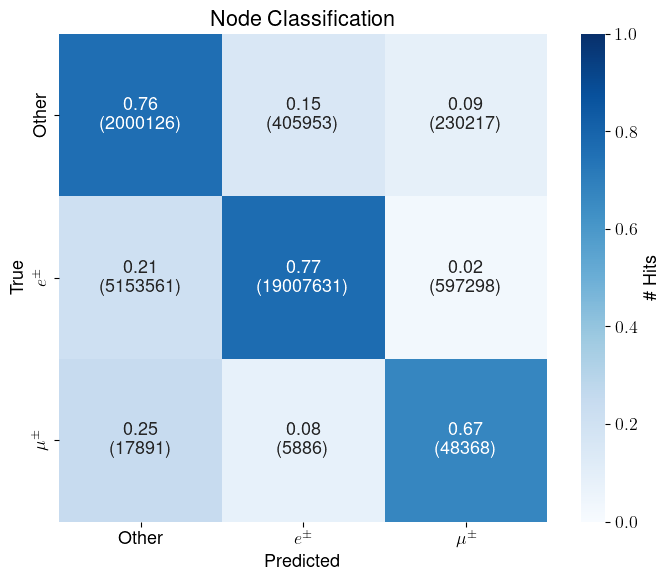

In [103]:
plot_confusion_matrix(
    y_node_true_flat,
    y_node_pred_flat,
    normalize=True,
    class_names=[hit.latex_name for hit in hits],
    cbar_label=r"\# Hits",
    title="Node Classification",
)

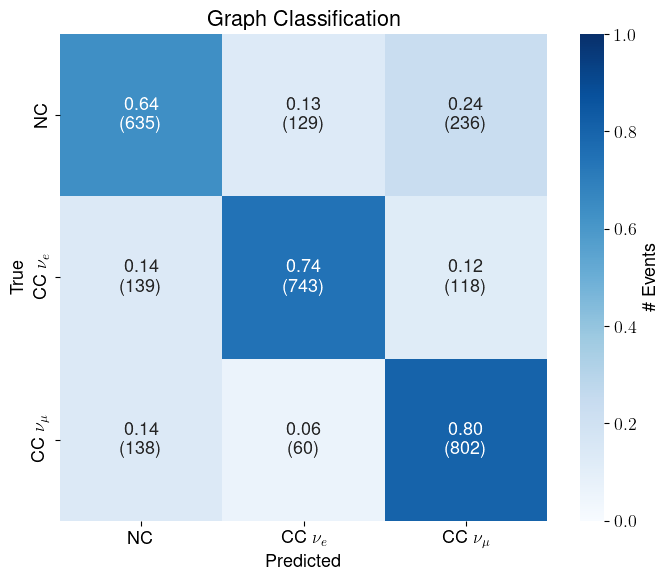

In [104]:
plot_confusion_matrix(
    y_graph_true_flat,
    y_graph_pred_flat,
    normalize=True,
    class_names=[nu.latex_name for nu in nus],
    cbar_label=r"\# Events",
    title="Graph Classification",
)

In [115]:
truth_df.loc[:, "E_nu_bin"] = pd.cut(
    truth_df["E_nu"], bins=np.arange(0, 1200e3 + 1e-3, 100e3), labels=False
)

In [172]:
len([npdataset[i].x_faser.numpy() for i in mask])

3000

In [181]:
faser_nc = np.array([dataset[i].x_faser.numpy() for i in range(len(dataset))])[mask]

In [185]:
faser_nc[:, 0]

array([ 3.,  3.,  5.,  2.,  5., 19.,  0.,  1.,  0.,  5.,  3.,  3.,  1.,
        0.,  1.,  0.,  1.,  0.,  5.,  5.,  1., 13.,  4.,  4.,  0.,  2.,
       12.,  1.,  5.,  2.,  3.,  1.,  6.,  3.,  2., 23.,  0.,  1.,  6.,
        3.,  1.,  0.,  3.,  1.,  2.,  2.,  0.,  5.,  1.,  1.,  2.,  2.,
        4.,  6.,  8.,  2.,  1.,  8.,  3.,  0.,  1.,  2.,  1.,  2.,  0.,
        1.,  0.,  5.,  2.,  0.,  3.,  0.,  5.,  0., 19.,  0.,  2.,  3.,
        0.,  4.,  0.,  0.,  4.,  3.,  1.,  2.,  2.,  5.,  0.,  0.,  0.,
        1.,  1.,  3.,  2.,  1.,  2.,  1.,  0.,  0.,  1.,  3.,  0.,  2.,
        0.,  2.,  1.,  1.,  2.,  0.], dtype=float32)

In [192]:
faser_df = pd.DataFrame(
    np.array([dataset[i].x_faser.numpy() for i in range(len(dataset))]),
    columns=["n0", "n1", "n2", "x", "y"],
)

In [ ]:
nc_mask = (abs(truth_df["pdg_lepton"]).isin([12, 14, 16])) & (truth_df["vz"] > 1300)
faser_nc_df = faser_df.loc[nc_mask]

In [213]:
cc_mu_mask = (abs(truth_df["pdg_lepton"]).isin([13])) & (truth_df["vz"] > 1300)
faser_cc_mu_df = faser_df.loc[cc_mu_mask]

In [215]:
import hist
import mplhep

In [217]:
faser_nc_df

,n0,n1,n2,x,y
2047,3.0,3.0,3.0,-0.018281,0.041889
2059,3.0,3.0,3.0,-0.024429,-0.033155
2082,5.0,5.0,3.0,0.055017,0.061438
2085,2.0,2.0,2.0,-0.014782,0.098430
2090,5.0,5.0,3.0,0.012811,0.083410
...,...,...,...,...,...
2937,2.0,1.0,1.0,0.000382,0.002160
2958,1.0,0.0,0.0,0.791042,0.618050
2968,1.0,0.0,0.0,0.194041,0.636054
2979,2.0,2.0,2.0,0.146568,-0.411768


In [218]:
faser_cc_mu_df

,n0,n1,n2,x,y
1026,2.0,2.0,2.0,0.033424,-0.001598
1040,3.0,2.0,0.0,-0.395598,0.260342
1057,1.0,1.0,1.0,-0.075082,0.002252
1060,7.0,7.0,4.0,-6.542636,0.976460
1061,0.0,0.0,0.0,-1.029198,0.134271
...,...,...,...,...,...
1972,1.0,1.0,0.0,0.142288,0.374608
1975,6.0,6.0,6.0,0.047671,0.068032
1979,22.0,19.0,15.0,-0.019170,-0.022792
1983,2.0,1.0,1.0,-0.003547,-0.040936


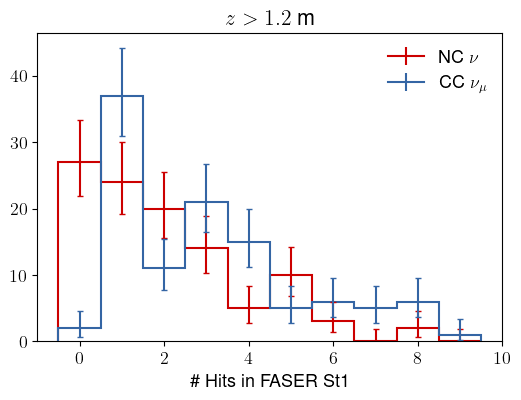

In [226]:
h = hist.Hist(hist.axis.Variable(np.arange(-0.5, 10.5, 1)))
fig, ax = plt.subplots(figsize=(6, 4))

for df, label, color in zip(
    [faser_nc_df, faser_cc_mu_df],
    [r"NC $\nu$", r"CC $\nu_{\mu}$"],
    [TangoColors.scarlet_red, TangoColors.sky_blue],
):
    h.reset()
    h.fill(df["n0"])
    mplhep.histplot(h, ax=ax, label=label, histtype="step", color=color, flow=None)
ax.set_xlabel(r"\# Hits in FASER St1")
ax.set_title(r"$z > 1.2$ m")
ax.legend()
plt.show()

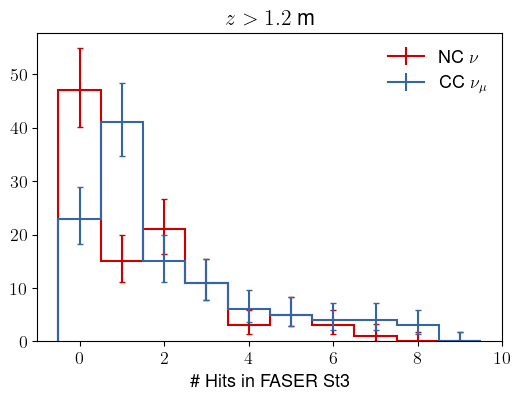

In [227]:
h = hist.Hist(hist.axis.Variable(np.arange(-0.5, 10.5, 1)))
fig, ax = plt.subplots(figsize=(6, 4))

for df, label, color in zip(
    [faser_nc_df, faser_cc_mu_df],
    [r"NC $\nu$", r"CC $\nu_{\mu}$"],
    [TangoColors.scarlet_red, TangoColors.sky_blue],
):
    h.reset()
    h.fill(df["n2"])
    mplhep.histplot(h, ax=ax, label=label, histtype="step", color=color, flow=None)
ax.set_xlabel(r"\# Hits in FASER St3")
ax.set_title(r"$z > 1.2$ m")
ax.legend()
plt.show()

In [190]:
faser_nc.query("n0 > 0")

,n0,n1,n2,x,y
2047,1.0,0.0,0.0,0.177537,0.159341
2059,1.0,0.0,0.0,0.177537,0.159341
2082,1.0,0.0,0.0,0.177537,0.159341
2085,1.0,0.0,0.0,0.177537,0.159341
2090,1.0,0.0,0.0,0.177537,0.159341
...,...,...,...,...,...
2937,1.0,0.0,0.0,0.177537,0.159341
2958,1.0,0.0,0.0,0.177537,0.159341
2968,1.0,0.0,0.0,0.177537,0.159341
2979,1.0,0.0,0.0,0.177537,0.159341


In [164]:
faser_nc

array([[0.        , 0.        , 0.        , 0.08402511, 0.54691225],
       [0.        , 0.        , 0.        , 0.08402511, 0.54691225],
       [0.        , 0.        , 0.        , 0.08402511, 0.54691225],
       ...,
       [0.        , 0.        , 0.        , 0.08402511, 0.54691225],
       [0.        , 0.        , 0.        , 0.08402511, 0.54691225],
       [0.        , 0.        , 0.        , 0.08402511, 0.54691225]],
      shape=(3000, 5), dtype=float32)

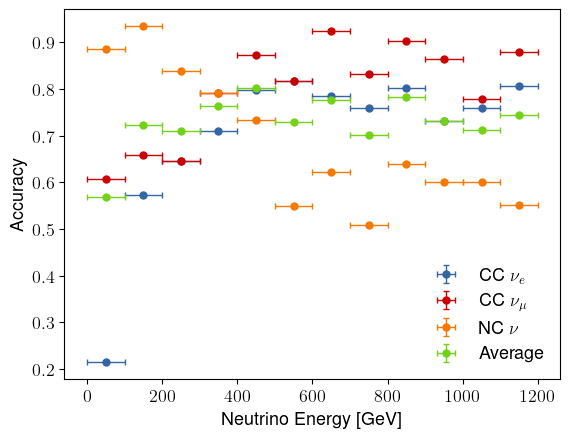

In [137]:
e_nu = truth_df["E_nu"].values
nu_energy_edges = np.arange(0, 1200e3 + 1e-3, 100e3)
nu_energy_centers = (nu_energy_edges[:-1] + nu_energy_edges[1:]) / 2
e_nu_bins = pd.cut(e_nu, bins=nu_energy_edges, labels=False)

acc_dicts = []
for i in range(12):
    bin_indices = np.where(e_nu_bins == i)[0]
    y_true_bin = y_graph_true_flat[bin_indices]
    y_pred_bin = y_graph_pred_flat[bin_indices]
    acc_dict = get_accuracy_dict(
        y_true=y_true_bin, y_pred=y_pred_bin, class_names=[nu.label for nu in nus]
    )
    acc_dicts.append(acc_dict)

combined_acc_dict = {}
for key in ["nue", "num", "nun", "average"]:
    combined_acc_dict[key] = [acc_dict[key] for acc_dict in acc_dicts]
acc_df = pd.DataFrame(combined_acc_dict)
acc_df.loc[:, "energy"] = nu_energy_centers * 1e-3

# fig, ax = plt.subplots()
# for key in ["nue", "num", "nun", "average"]:
#     plt.scatter(acc_df["energy"], acc_df[key])

fig, ax = plt.subplots()
for key, label in zip(
    ["nue", "num", "nun", "average"],
    [r"CC $\nu_e$", r"CC $\nu_\mu$", r"NC $\nu$", "Average"],
):
    mplhep.histplot(
        acc_df[key].values,
        bins=nu_energy_edges * 1e-3,
        histtype="errorbar",
        xerr=True,
        label=label,
    )
ax.legend()
ax.set_xlabel(r"Neutrino Energy [GeV]")
ax.set_ylabel("Accuracy")
plt.show()

In [146]:
def compute_binned_accuracy(
    truth_variable,
    bin_edges,
    y_true,
    y_pred,
    class_names,
    bin_center_scale=1.0,
    bin_center_column="bin_center",
):
    """
    Compute accuracy in bins of a truth variable.

    Args:
        truth_variable: Array of truth values to bin (e.g., neutrino energy, vertex z)
        bin_edges: Bin edges for binning truth_variable
        y_true: True class labels
        y_pred: Predicted class labels
        class_names: List of class names (e.g., ['nue', 'num', 'nun'])
        bin_center_scale: Scale factor for bin centers (e.g., 1e-3 to convert MeV to GeV)
        bin_center_column: Name of the column for bin centers in output dataframe

    Returns:
        DataFrame with accuracies for each class and bin
    """
    # Compute bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Bin the truth variable
    bins = pd.cut(truth_variable, bins=bin_edges, labels=False)

    # Compute accuracy for each bin
    n_bins = len(bin_edges) - 1
    acc_dicts = []
    for i in range(n_bins):
        bin_indices = np.where(bins == i)[0]

        if len(bin_indices) > 0:
            y_true_bin = y_true[bin_indices]
            y_pred_bin = y_pred[bin_indices]
            acc_dict = get_accuracy_dict(
                y_true=y_true_bin, y_pred=y_pred_bin, class_names=class_names
            )
        else:
            # No events in this bin
            acc_dict = {name: np.nan for name in class_names}
            acc_dict["average"] = np.nan

        acc_dicts.append(acc_dict)

    # Combine into dataframe
    combined_acc_dict = {}
    for key in list(class_names) + ["average"]:
        combined_acc_dict[key] = [acc_dict[key] for acc_dict in acc_dicts]

    acc_df = pd.DataFrame(combined_acc_dict)
    acc_df[bin_center_column] = bin_centers * bin_center_scale

    return acc_df

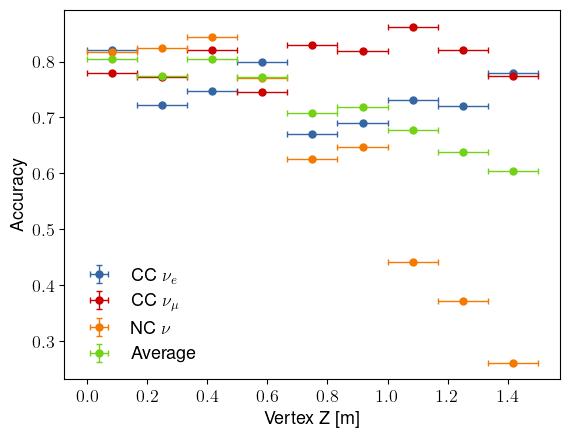

In [147]:
# Example usage: Accuracy vs vertex z
e_nu = truth_df["vz"].values
nu_energy_edges = np.linspace(0, 1500, 10)

acc_df = compute_binned_accuracy(
    truth_variable=e_nu,
    bin_edges=nu_energy_edges,
    y_true=y_graph_true_flat,
    y_pred=y_graph_pred_flat,
    class_names=[nu.label for nu in nus],
    bin_center_scale=1e-3,
    bin_center_column="vz",
)

# Plot
fig, ax = plt.subplots()
for key, label in zip(
    ["nue", "num", "nun", "average"],
    [r"CC $\nu_e$", r"CC $\nu_\mu$", r"NC $\nu$", "Average"],
):
    mplhep.histplot(
        acc_df[key].values,
        bins=nu_energy_edges * 1e-3,
        histtype="errorbar",
        xerr=True,
        label=label,
    )
ax.legend()
ax.set_xlabel(r"Vertex Z [m]")
ax.set_ylabel("Accuracy")
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
# plot_precision_recall_curve(
#     y_true=y_node_true_flat,
#     y_prob=y_node_prob_flat,
#     class_names=[nu.latex_name for nu in nus],
# )

In [106]:
# plot_roc_curve(
#     y_true=y_node_true_flat,
#     y_prob=y_node_prob_flat,
#     class_names=[hit.latex_name for hit in hits],
#     figure_path=figures_path / "roc_curve.png",
# )

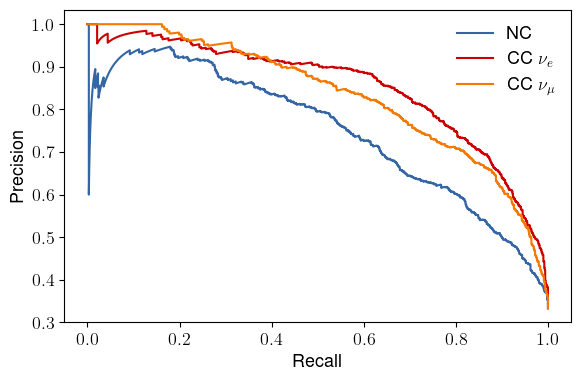

In [107]:
plot_precision_recall_curve(
    y_true=y_graph_true_flat,
    y_prob=y_graph_prob_flat,
    class_names=[nu.latex_name for nu in nus],
)

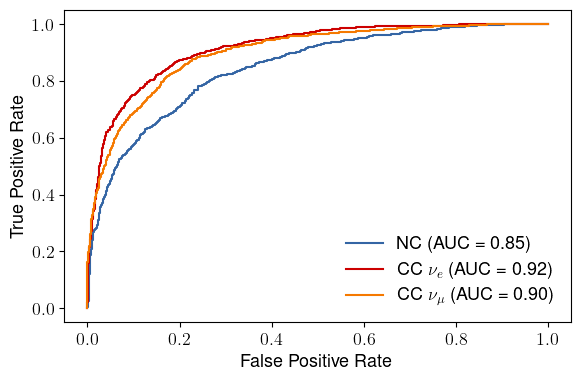

In [108]:
plot_roc_curve(
    y_true=y_graph_true_flat,
    y_prob=y_graph_prob_flat,
    class_names=[nu.latex_name for nu in nus],
    figure_path=figures_path / "roc_curve.png",
)

1000.0
1000.0
1000.0


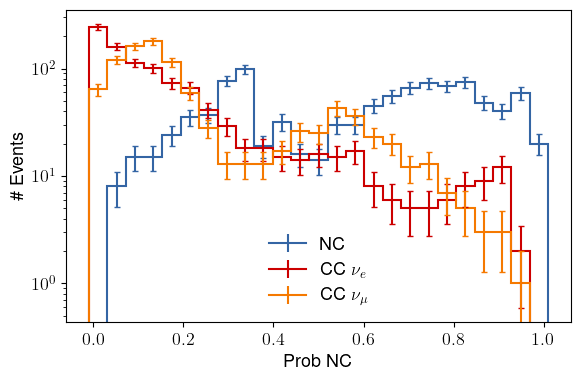

1000.0
1000.0
1000.0


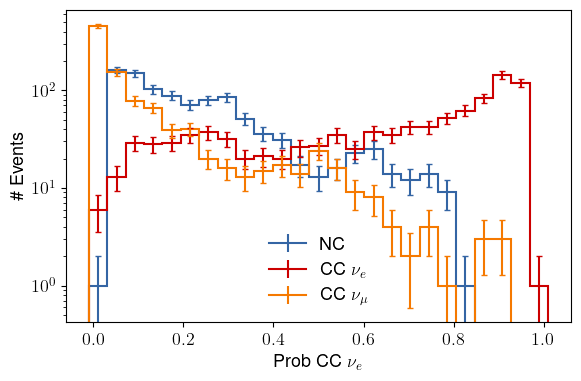

1000.0
1000.0
1000.0


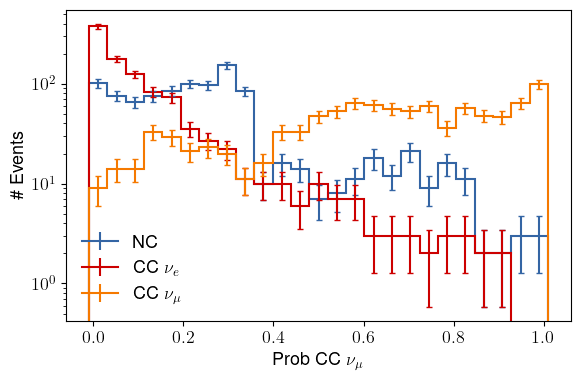

In [109]:
plot_probabilities(
    y_true=y_graph_true_flat,
    y_prob=y_graph_prob_flat,
    class_names=[nu.latex_name for nu in nus],
    yscale="log",
    num_bins=25,
)

In [110]:
def optimize_probability_cut(
    y_true, y_prob, signal_class, threshold_range=np.linspace(0, 1, 101)
):
    """
    Optimize probability cut to maximize figure of merit s/sqrt(s+b).

    Args:
        y_true: True class labels
        y_prob: Predicted probabilities for each class
        signal_class: Index of the signal class
        threshold_range: Array of thresholds to scan

    Returns:
        optimal_threshold: Threshold that maximizes FOM
        optimal_fom: Maximum FOM value
        efficiency: Signal efficiency at optimal threshold
        background_rejection: Background rejection at optimal threshold
        results: Dictionary with all threshold scan results
    """
    # Get probability for signal class
    y_prob_signal = y_prob[:, signal_class]

    # Define signal and background masks
    is_signal = y_true == signal_class
    is_background = ~is_signal

    total_signal = is_signal.sum()
    total_background = is_background.sum()

    # Arrays to store results
    foms = []
    efficiencies = []
    background_rejections = []
    signal_counts = []
    background_counts = []

    for threshold in threshold_range:
        # Events passing the cut
        passes_cut = y_prob_signal >= threshold

        # Count signal and background passing cut
        s = (is_signal & passes_cut).sum()
        b = (is_background & passes_cut).sum()

        # Calculate FOM
        if s + b > 0:
            fom = s / np.sqrt(s + b)
        else:
            fom = 0

        # Calculate efficiency and background rejection
        efficiency = s / total_signal if total_signal > 0 else 0
        background_rejection = 1 - (b / total_background) if total_background > 0 else 1

        foms.append(fom)
        efficiencies.append(efficiency)
        background_rejections.append(background_rejection)
        signal_counts.append(s)
        background_counts.append(b)

    # Find optimal threshold
    foms = np.array(foms)
    efficiencies = np.array(efficiencies)
    background_rejections = np.array(background_rejections)

    optimal_idx = np.argmax(foms)
    optimal_threshold = threshold_range[optimal_idx]
    optimal_fom = foms[optimal_idx]
    optimal_efficiency = efficiencies[optimal_idx]
    optimal_background_rejection = background_rejections[optimal_idx]

    results = {
        "thresholds": threshold_range,
        "foms": foms,
        "efficiencies": efficiencies,
        "background_rejections": background_rejections,
        "signal_counts": np.array(signal_counts),
        "background_counts": np.array(background_counts),
    }

    return (
        optimal_threshold,
        optimal_fom,
        optimal_efficiency,
        optimal_background_rejection,
        results,
    )


# Example: Optimize for CC νμ as signal (class 2)
for signal_class in range(3):
    print("-" * 40)
    print("class:", signal_class)
    opt_threshold, opt_fom, opt_eff, opt_bg_rej, results = optimize_probability_cut(
        y_graph_true_flat, y_graph_prob_flat, signal_class=signal_class
    )

    print(f"Signal class: {nus[signal_class].latex_name}")
    print(f"Optimal threshold: {opt_threshold:.3f}")
    print(f"Maximum FOM (s/√(s+b)): {opt_fom:.2f}")
    print(f"Signal efficiency: {opt_eff:.3f} ({opt_eff * 100:.1f}%)")
    print(f"Background rejection: {opt_bg_rej:.3f} ({opt_bg_rej * 100:.1f}%)")
    print(f"\nAt optimal cut:")
    print(
        f"  Signal events: {results['signal_counts'][np.argmax(results['foms'])]:.0f}"
    )
    print(
        f"  Background events: {results['background_counts'][np.argmax(results['foms'])]:.0f}"
    )
    print("-" * 40)

----------------------------------------
class: 0
Signal class: NC
Optimal threshold: 0.310
Maximum FOM (s/√(s+b)): 21.95
Signal efficiency: 0.816 (81.6%)
Background rejection: 0.717 (71.7%)

At optimal cut:
  Signal events: 816
  Background events: 566
----------------------------------------
----------------------------------------
class: 1
Signal class: CC $\nu_{e}$
Optimal threshold: 0.230
Maximum FOM (s/√(s+b)): 24.56
Signal efficiency: 0.868 (86.8%)
Background rejection: 0.809 (81.0%)

At optimal cut:
  Signal events: 868
  Background events: 381
----------------------------------------
----------------------------------------
class: 2
Signal class: CC $\nu_{\mu}$
Optimal threshold: 0.240
Maximum FOM (s/√(s+b)): 23.99
Signal efficiency: 0.877 (87.7%)
Background rejection: 0.770 (77.0%)

At optimal cut:
  Signal events: 877
  Background events: 459
----------------------------------------


In [71]:
n_sig = results["signal_counts"][results["thresholds"] == 0.5]
n_bkg = results["background_counts"][results["thresholds"] == 0.5]
print(f"At 0.5 cut: signal={n_sig[0]}, background={n_bkg[0]}")

At 0.5 cut: signal=1039, background=312


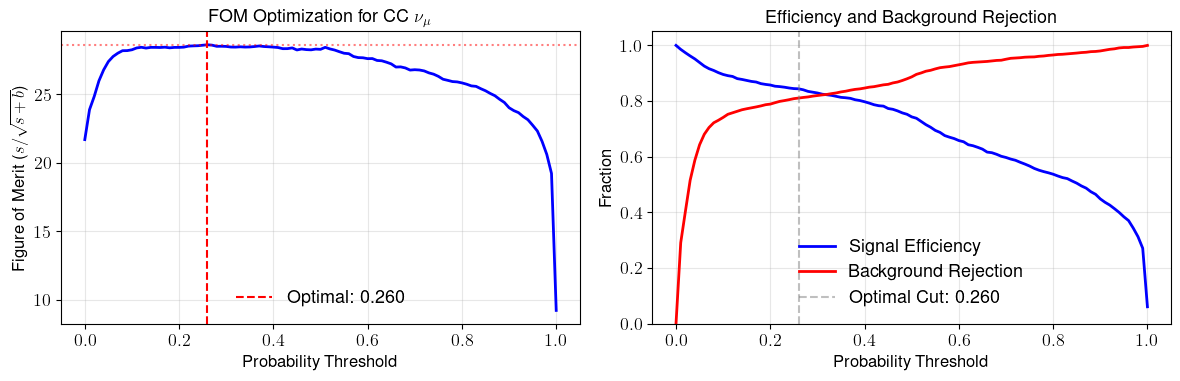

In [59]:
# Plot FOM vs threshold
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: FOM vs threshold
ax1.plot(results["thresholds"], results["foms"], "b-", linewidth=2)
ax1.axvline(
    opt_threshold, color="r", linestyle="--", label=f"Optimal: {opt_threshold:.3f}"
)
ax1.axhline(opt_fom, color="r", linestyle=":", alpha=0.5)
ax1.set_xlabel("Probability Threshold", fontsize=12)
ax1.set_ylabel(r"Figure of Merit ($s/\sqrt{s+b}$)", fontsize=12)
ax1.set_title(f"FOM Optimization for {nus[signal_class].latex_name}", fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Right: Efficiency and background rejection vs threshold
ax2.plot(
    results["thresholds"],
    results["efficiencies"],
    "b-",
    linewidth=2,
    label="Signal Efficiency",
)
ax2.plot(
    results["thresholds"],
    results["background_rejections"],
    "r-",
    linewidth=2,
    label="Background Rejection",
)
ax2.axvline(
    opt_threshold,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label=f"Optimal Cut: {opt_threshold:.3f}",
)
ax2.set_xlabel("Probability Threshold", fontsize=12)
ax2.set_ylabel("Fraction", fontsize=12)
ax2.set_title("Efficiency and Background Rejection", fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

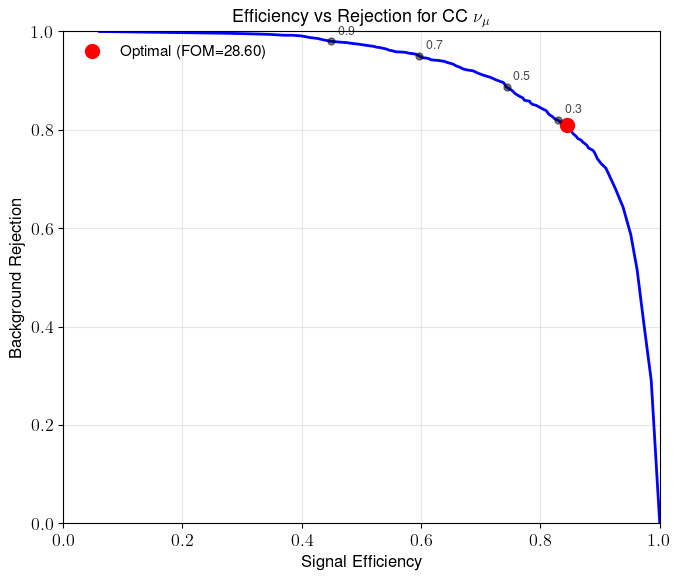

In [72]:
# ROC-style curve: Signal efficiency vs background rejection
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(results["efficiencies"], results["background_rejections"], "b-", linewidth=2)
ax.plot(opt_eff, opt_bg_rej, "ro", markersize=10, label=f"Optimal (FOM={opt_fom:.2f})")
ax.set_xlabel("Signal Efficiency", fontsize=12)
ax.set_ylabel("Background Rejection", fontsize=12)
ax.set_title(f"Efficiency vs Rejection for {nus[signal_class].latex_name}", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add some threshold markers
for thresh in [0.3, 0.5, 0.7, 0.9]:
    idx = np.argmin(np.abs(results["thresholds"] - thresh))
    ax.plot(
        results["efficiencies"][idx],
        results["background_rejections"][idx],
        "ko",
        markersize=5,
        alpha=0.5,
    )
    ax.annotate(
        f"{thresh:.1f}",
        xy=(results["efficiencies"][idx], results["background_rejections"][idx]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        alpha=0.7,
    )

plt.tight_layout()
plt.show()